Universidad Torcuato Di Tella

Licenciatura en Tecnología Digital

**Aplicaciones Computacionales en Negocios**

# **Trabajo Práctico N°1 — Sistema de abordaje de pasajeros en un avión**

Propon ́e de manera precisa una regla de comportamiento de pasajeros
Pens ́a en tu experiencia o busc ́a videos y responde: cu ́anto tarda en levantarse y dejar
lugar un pasajero sentado en el pasillo para que pase un pasajero que va a ventana?
Si una persona llega a su fila y su asiento est ́a vac ́ıo, cu ́anto tarde en sentarse? y si
tiene carry on?

Desde el momento en que un pasajero sube el avión, tiene un repertorio limitado de acciones:
- Avanzar.
- Levantarse.
- Guardar equipaje.
- Sentarse.

Asimismo, pueden adoptar algunos de los siguientes estados:
- Posición actual.
- Asiento.
- Asiento conseguido.
- Tiene carry-on (a mano).
- Sentado.
- Pasajero delante (en pasillo central).
- Pasajero en pasillo (ya estando sentado en fila junto al pasillo).

Vamos a asumir las siguientes reglas de comportamiento para los pasajeros:
- El pasajero que llega a su asiento vacío y no posee carry-on se demora de 4 a 12 segundos en sentarse.
- El pasajero que llega a su asiento vacío y que sí posee carry-on se demora de 12 a 32 segundos en sentarse.
- Cada pasajero que debe levantarse para habilitar la llegada al asiento agrega de 3 a 5 segundos al tiempo total de onboarding.
- Si se requiere guardar el carry-on y esperar para sentarse, necesariamente se debe guardar el carry-on primero para luego esperar a que se le deje pasar.



In [1]:
import random
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.figure as figure
from IPython.display import Image, display

# Ubicamos la raíz del repositorio sin depender de desde dónde se abra el
# notebook: subimos carpeta por carpeta hasta encontrar rutas.py
import sys
from pathlib import Path
raiz = Path.cwd()
while not (raiz / 'rutas.py').exists():
    raiz = raiz.parent
sys.path.append(str(raiz))

# rutas.py deja simulacion/ y analisis/ en el path
import rutas

from ambiente_fisico import PlaneModel
from runner import run_simulations, save_results, run_and_show
from lectura_resultados import leer_carpeta, leer_resultados

In [2]:
METODOS = {'rand': 'Aleatorio', 'btf': 'Back-to-Front', 'wilma': 'WilMA', 'stfn': 'Steffen'}

METODO = 'rand'   # probar con 'btf', 'wilma' o 'stfn'
random.seed(42)   # para que la animación sea reproducible

model = PlaneModel(n=100, p=0.5, onboarding_method=METODO)


In [3]:
N_SIMULACIONES = 100
N_PASAJEROS = 100
P_CARRYON = 0.65

In [4]:
# results = run_simulations(n_simulations=N_SIMULACIONES, n_passengers=N_PASAJEROS, p_carryon=P_CARRYON)
# save_results(results = results, n_passengers=N_PASAJEROS, p_carryon=P_CARRYON)

In [5]:
# Prueba de visualización

# from runner import run_and_show
# gif = run_and_show(N_PASAJEROS, 0.5, method='rand')

## Estadísticas

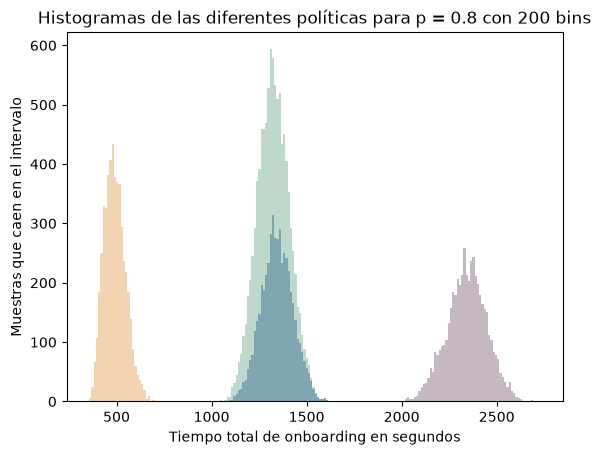

In [ ]:
# Probamos lectura de carpetas y lectura de archivos

r = leer_resultados('p_08.txt')

n_bins = 200
data_btf = r.tiempos('btf')
data_rand = r.tiempos('rand')
data_wilma = r.tiempos('wilma')
data_stfn = r.tiempos('stfn')
colores = [(140/255, 114/255, 132/255, 0.5),(0, 78/255, 100/255, 0.5),(94/255, 11/255, 21/255, 0.5),(230/255, 170/255, 104/255, 0.5)]

plt.hist([data_btf, data_rand, data_wilma, data_stfn], n_bins, label=labels, stacked=True, fill=True, color=colores)
plt.title("Histogramas de las diferentes políticas para p = 0.8 con 200 bins")
plt.xlabel("Tiempo total de onboarding en segundos")
plt.ylabel("Muestras que caen en el intervalo")

plt.show()




In [7]:
b = leer_carpeta()